Time-Senstive QA Exploration

This notebook performs exploratory analysis on the Time-Sensitive QA (TS-QA) dataset (Hugging Face: Catkamakura/ts-qa) to support our Contradiction-Aware Sparse Memory Finetuning continual learning project.

TS-QA is a temporal QA benchmark where the correct answer can change over time. Each example includes:
- a time-scoped question (often prefixed with a specific date),
- a supporting context passage (evidence),
- timestamps for the question and evidence,
- metadata describing critical dimensions (entity/relation constraints),
- and hard negatives / perturbed variants that can introduce contradiction-like failure cases.

The dataset contains multiple sources:
- streammingpa, timeqa, plus *_perturbed variants 

Things we would want to understand:
To design versioned memory + routing (time/context-aware retrieval), we want to quantify:
1. Dataset composition: split sizes; source distribution (streamingqa vs timeqa vs perturbed).
2. Temporal signal: how far the question timestamp is from the evidence timestamp (gap distribution), and how often timestamps are missing.
3. Contradiction / confusion risk: prevalence of is_hard_negative and how it varies by source.
4. Question metadata: distribution of question_type and how often questions have critical dimensions (i.e., likely to change answer under different temporal/entity constraints).
5. Text characteristics: question/context length distributions (proxy for difficulty + compute needs).

These analyses guide how we:
- detect updates/contradictions,
- decide what should be written into sparse memory slots, 
- and later train a router to select the correct “version” at inference time.

Install Dependencies:
pip install datasets pandas numpy matplotlib


1. TS-QA: Setup + Load + Quick Sanity Checks


In [17]:
from datasets import load_dataset
from collections import Counter
import pandas as pd
import numpy as np
from datetime import datetime
import json
import random

# Load dataset
tsqa = load_dataset("Catkamakura/ts-qa")
print(tsqa)
print("Splits:", list(tsqa.keys()))

train = tsqa["train"]
val = tsqa["validation"] if "validation" in tsqa else tsqa.get("val", None)
test = tsqa["test"]

print("\nTrain rows:", len(train))
print("Columns:", train.column_names)

# Peek one example
ex = train[0]
print("\nExample keys:", ex.keys())
print("Question:", ex.get("question"))
print("Answers:", ex.get("answers"))
print("Source:", ex.get("source"))
print("Question timestamp:", ex.get("question_timestamp"))
print("Evidence timestamp:", ex.get("evidence_timestamp"))
print("Hard negative:", ex.get("is_hard_negative"))

# Source distribution + hard negative rate
src_counts = Counter(train["source"])
hn_rate = float(np.mean([bool(x) for x in train["is_hard_negative"]]))
print("\nSource counts:", src_counts)
print("Hard-negative rate:", round(hn_rate, 4))

# Timestamp gap utility (robust to missing/blank timestamps)
def parse_ts(s):
    if s is None:
        return None
    s = str(s).strip()
    if s == "":
        return None
    return datetime.fromisoformat(s)

gaps = []
missing_ts = 0
for qts, ets in zip(train["question_timestamp"], train["evidence_timestamp"]):
    qdt, edt = parse_ts(qts), parse_ts(ets)
    if qdt is None or edt is None:
        missing_ts += 1
        continue
    gaps.append((qdt - edt).days)

print("\nTimestamp gaps computed:", len(gaps))
print("Rows skipped (missing/blank timestamp):", missing_ts)
print(pd.Series(gaps).describe())

DatasetDict({
    train: Dataset({
        features: ['id', 'question', 'context', 'answers', 'source', 'question_timestamp', 'evidence_timestamp', 'dimensions', 'is_hard_negative', 'original_question'],
        num_rows: 25041
    })
    validation: Dataset({
        features: ['id', 'question', 'context', 'answers', 'source', 'question_timestamp', 'evidence_timestamp', 'dimensions', 'is_hard_negative', 'original_question'],
        num_rows: 2800
    })
    test: Dataset({
        features: ['id', 'question', 'context', 'answers', 'source', 'question_timestamp', 'evidence_timestamp', 'dimensions', 'is_hard_negative', 'original_question'],
        num_rows: 9089
    })
})
Splits: ['train', 'validation', 'test']

Train rows: 25041
Columns: ['id', 'question', 'context', 'answers', 'source', 'question_timestamp', 'evidence_timestamp', 'dimensions', 'is_hard_negative', 'original_question']

Example keys: dict_keys(['id', 'question', 'context', 'answers', 'source', 'question_timestamp', 'e

2. Split and source composition

We first quantify the dataset size across splits and the distribution of examples by source. TS-QA contains examples from streamingqa and timeqa, along with *_perturbed variants designed to stress temporal robustness and contradiction-like confusions. Understanding the mixture of sources will help us decide how to sample training data and how to evaluate memory behavior across different settings.

In [18]:
# Split sizes
split_sizes = {k: len(v) for k, v in tsqa.items()}
print("Split sizes:", split_sizes)

# Source distribution (train)
src_counts = Counter(train["source"])
src_df = pd.DataFrame(src_counts.items(), columns=["source", "count"]).sort_values("count", ascending=False)
src_df["pct"] = src_df["count"] / len(train)
display(src_df)

# Hard negatives overall + by source
hn_overall = float(np.mean([bool(x) for x in train["is_hard_negative"]]))
print("Hard-negative rate (overall):", round(hn_overall, 4))

hn_by_source = (
    pd.DataFrame({"source": train["source"], "is_hard_negative": train["is_hard_negative"]})
      .groupby("source")["is_hard_negative"]
      .mean()
      .sort_values(ascending=False)
)
display(hn_by_source.to_frame("hard_negative_rate"))

Split sizes: {'train': 25041, 'validation': 2800, 'test': 9089}


,source,count,pct
0,streamingqa,19778,0.789825
1,streamingqa_perturbed,3932,0.157022
2,timeqa,1032,0.041212
3,timeqa_perturbed,299,0.011940


Hard-negative rate (overall): 0.169


,hard_negative_rate
source,
streamingqa_perturbed,1.0
timeqa_perturbed,1.0
streamingqa,0.0
timeqa,0.0


3. Timestamp gaps (temporal drift)

A central challenge in time-sensitive QA is that the correct answer depends on time. We measure the gap (in days) between the question timestamp and the evidence timestamp. Large gaps can indicate higher temporal drift and higher risk of retrieving outdated facts. We also track missing timestamps and exclude those examples from the gap computation.


In [19]:
def parse_ts(s):
    if s is None:
        return None
    s = str(s).strip()
    if s == "":
        return None
    return datetime.fromisoformat(s)

def gap_days(qts, ets):
    qdt, edt = parse_ts(qts), parse_ts(ets)
    if qdt is None or edt is None:
        return None
    return (qdt - edt).days

# Overall gaps (train)
gaps = []
missing_ts = 0
for qts, ets in zip(train["question_timestamp"], train["evidence_timestamp"]):
    g = gap_days(qts, ets)
    if g is None:
        missing_ts += 1
    else:
        gaps.append(g)

print("Computed gaps:", len(gaps))
print("Missing/blank timestamps:", missing_ts, f"({missing_ts/len(train):.2%})")
display(pd.Series(gaps).describe())

# Gaps by source
rows = []
for ex in train:
    g = gap_days(ex["question_timestamp"], ex["evidence_timestamp"])
    if g is not None:
        rows.append((ex["source"], g))

gap_df = pd.DataFrame(rows, columns=["source", "gap_days"])
display(gap_df.groupby("source")["gap_days"].describe())

Computed gaps: 23710
Missing/blank timestamps: 1331 (5.32%)


count    23710.000000
mean       305.218979
std        539.887104
min          0.000000
25%         14.000000
50%         28.000000
75%        370.000000
max       4395.000000
dtype: float64

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
streamingqa,19778.0,306.910355,542.555726,0.0,14.0,28.0,371.0,4395.0
streamingqa_perturbed,3932.0,296.711343,526.243901,0.0,14.0,27.0,360.0,4029.0


4. Dimensions metadata (question types + critical dimensions)

TS-QA provides a dimensions field with structured metadata (serialized JSON). We parse this field to estimate:
- the distribution of question_type (e.g., factoid vs temporal), and
- the proportion of questions marked as having critical dimensions, indicating that changing entity/relation/time constraints would likely change the answer.

These signals connect directly to our contradiction-aware memory goal: facts with critical dimensions are more likely to require versioned storage and careful retrieval.


In [20]:
qtype = Counter()
has_critical = 0
parse_fail = 0

for d in train["dimensions"]:
    try:
        obj = json.loads(d)
        qtype[obj.get("question_type", "UNK")] += 1
        if obj.get("has_critical_dimensions"):
            has_critical += 1
    except Exception:
        parse_fail += 1
        qtype["UNK"] += 1

print(type(train["dimensions"][0]))
print(train["dimensions"][0])
print("Question type distribution:", qtype)
print("Has critical dimensions rate:", has_critical / len(train))
print("Dimensions parse failures:", parse_fail)


<class 'str'>
{"dimensions": [{"type": "entity", "value": "Transport Minister of Thailand", "normalized": "Ministry of Transport, Thailand", "criticality": "high", "reason": "Different position or country would yield a different person"}], "question_type": "factoid", "has_critical_dimensions": true}
Question type distribution: Counter({'factoid': 18495, 'temporal': 5006, 'UNK': 1450, 'procedural': 90})
Has critical dimensions rate: 0.9392995487400663
Dimensions parse failures: 0


5. Text length Stats(question/context)

To estimate modeling and retrieval difficulty, we measure question and context lengths (characters as a quick proxy). Context length is particularly important for memory design because longer contexts can contain multiple entities/facts and may increase contradiction risk.


In [21]:
q_lens = [len(q) if q else 0 for q in train["question"]]
c_lens = [len(c) if c else 0 for c in train["context"]]
a_counts = [len(a) if a else 0 for a in train["answers"]]

stats = pd.DataFrame({
    "question_len_chars": q_lens,
    "context_len_chars": c_lens,
    "num_answers": a_counts
}).describe()

display(stats)

,question_len_chars,context_len_chars,num_answers
count,25041.000000,25041.000000,25041.000000
mean,87.381255,2761.173915,0.834432
std,23.688363,1579.994207,0.382189
min,17.000000,59.000000,0.000000
25%,71.000000,1535.000000,1.000000
50%,84.000000,2477.000000,1.000000
75%,100.000000,3677.000000,1.000000
max,212.000000,7931.000000,4.000000


Key Anaysis Findings so far(TS-QA)
From the training split (25,041 examples):

- Source composition: TS-QA is dominated by streamingqa (≈79%), with streamingqa_perturbed (≈16%), and smaller timeqa subsets (≈5% combined).
- Hard negatives: is_hard_negative aligns perfectly with perturbed sources (all *_perturbed are hard negatives; all non-perturbed are not). This provides an explicit set of contradiction/confusion stress tests.
- Temporal drift: For examples with valid timestamps (23,710), the median question–evidence gap is 28 days, with a long tail up to ~12 years, indicating both near-real-time and long-term temporal dependency. About 5.3% of rows have missing/blank timestamps and are excluded from the gap analysis.
- Question metadata: question_type is mostly factoid (18,495) with a sizable temporal subset (5,006). A large fraction of examples have critical dimensions (≈93.9%), suggesting answers are sensitive to time/entity constraints.

These properties make TS-QA a good fit for evaluating contradiction-aware memory: the perturbed/hard-negative subset explicitly challenges time-aware retrieval and version selection.

6. question_type & critical dims by source

In [22]:
rows = []
for src, d in zip(train["source"], train["dimensions"]):
    obj = json.loads(d)
    rows.append({
        "source": src,
        "question_type": obj.get("question_type", "UNK"),
        "has_critical_dimensions": bool(obj.get("has_critical_dimensions", False))
    })

df_dim = pd.DataFrame(rows)

print("Question type by source (counts):")
display(pd.crosstab(df_dim["source"], df_dim["question_type"]))

print("Question type by source (row %):")
display(pd.crosstab(df_dim["source"], df_dim["question_type"], normalize="index"))

print("Critical-dimension rate by source:")
display(df_dim.groupby("source")["has_critical_dimensions"].mean().to_frame("critical_dim_rate"))

Question type by source (counts):


question_type,UNK,factoid,procedural,temporal
source,,,,
streamingqa,194,15334,73,4177
streamingqa_perturbed,125,2961,17,829
timeqa,1001,31,0,0
timeqa_perturbed,130,169,0,0


Question type by source (row %):


question_type,UNK,factoid,procedural,temporal
source,,,,
streamingqa,0.009809,0.775306,0.003691,0.211194
streamingqa_perturbed,0.031790,0.753052,0.004323,0.210834
timeqa,0.969961,0.030039,0.000000,0.000000
timeqa_perturbed,0.434783,0.565217,0.000000,0.000000


Critical-dimension rate by source:


,critical_dim_rate
source,
streamingqa,0.987410
streamingqa_perturbed,0.964395
timeqa,0.030039
timeqa_perturbed,0.565217


7. contradiction stress” sanity check (perturbed vs clean examples)

In [23]:
# Pull a few clean vs perturbed examples to inspect differences
clean_idx = [i for i, s in enumerate(train["source"]) if "perturbed" not in s]
pert_idx  = [i for i, s in enumerate(train["source"]) if "perturbed" in s]

def show_example(i):
    ex = train[i]
    print("ID:", ex["id"])
    print("SOURCE:", ex["source"], "| hard_negative:", ex["is_hard_negative"])
    print("Q:", ex["question"])
    print("A:", ex["answers"])
    print("Q_ts:", ex["question_timestamp"], "E_ts:", ex["evidence_timestamp"])
    print("Context (first 300 chars):", ex["context"][:300].replace("\n"," "))
    print("-"*90)

print("=== Clean examples ===")
for i in random.sample(clean_idx, 2):
    show_example(i)

print("\n=== Perturbed (hard negative) examples ===")
for i in random.sample(pert_idx, 2):
    show_example(i)

=== Clean examples ===
ID: train-086644
SOURCE: streamingqa | hard_negative: False
Q: Today is Wednesday, July 9, 2014. When was the fire at Chemical Technology under control?
A: ['6 p.m.']
Q_ts: 2014-07-09T07:00:00 E_ts: 2013-11-15T08:00:00
Context (first 300 chars): Friday, November 15, 2013. Fire damages Detroit chemical company, forces evacuations A Detroit company that specializes in adhesives and paint was damaged Thursday by a fire that also forced the evacuation of surrounding homes and a nearby elementary school. The fire started early Thursday afternoon
------------------------------------------------------------------------------------------
ID: train-086679
SOURCE: streamingqa | hard_negative: False
Q: Today is Saturday, August 20, 2011. Which airline does Brian Simpson believe has perfected the art of the misleading flight costs?
A: ['Ryanair']
Q_ts: 2011-08-20T07:00:00 E_ts: 2008-07-09T07:00:00
Context (first 300 chars): Wednesday, July 9, 2008. Airlines will be banned fr

8. Simple plot, Timestap gap distribution by source, “Dataset stress profile” by source (critical dims + hard negatives)

Matplotlib is building the font cache; this may take a moment.


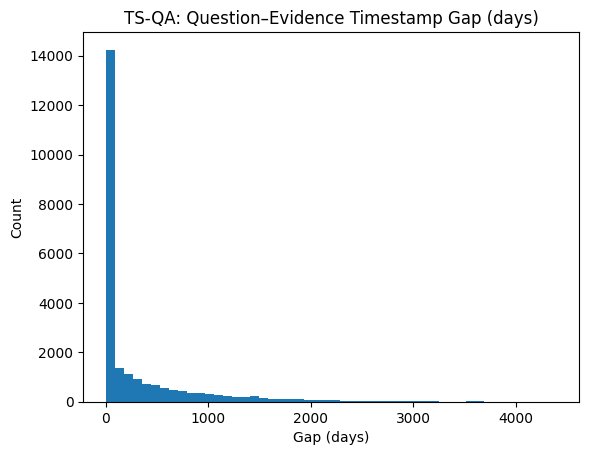

In [ ]:
import matplotlib.pyplot as plt

gap_series = pd.Series(gaps)

plt.figure()
plt.hist(gap_series, bins=50)
plt.title("TS-QA: Question–Evidence Timestamp Gap (days)")
plt.xlabel("Gap (days)")
plt.ylabel("Count")
plt.show()

/var/folders/52/cyv29smj783fmshj6yzkws6c0000gn/T/ipykernel_23714/4141876925.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)


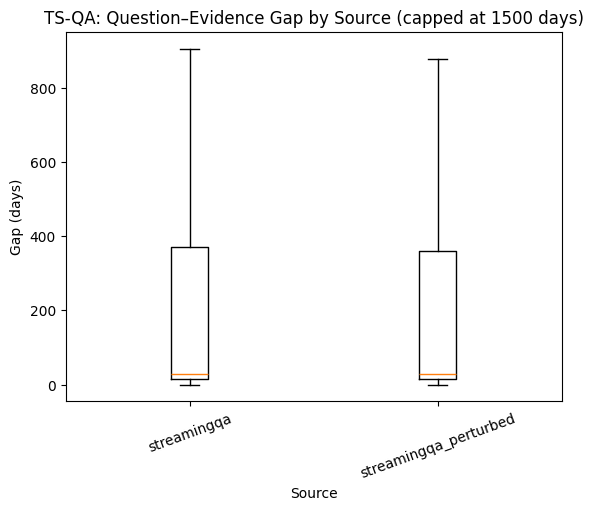

In [26]:
def parse_ts(s):
    if s is None:
        return None
    s = str(s).strip()
    if s == "":
        return None
    return datetime.fromisoformat(s)

def gap_days(qts, ets):
    qdt, edt = parse_ts(qts), parse_ts(ets)
    if qdt is None or edt is None:
        return None
    return (qdt - edt).days

# Build a dataframe of gaps
rows = []
for ex in train:
    g = gap_days(ex["question_timestamp"], ex["evidence_timestamp"])
    if g is not None:
        rows.append((ex["source"], g))

gap_df = pd.DataFrame(rows, columns=["source", "gap_days"])

# Optional: cap extreme tail so the boxplot is readable
CAP = 1500  # ~4 years; adjust to taste
gap_df["gap_days_capped"] = gap_df["gap_days"].clip(upper=CAP)

order = ["streamingqa", "streamingqa_perturbed", "timeqa", "timeqa_perturbed"]
order = [s for s in order if s in gap_df["source"].unique()]

data = [gap_df.loc[gap_df["source"] == s, "gap_days_capped"] for s in order]

plt.figure()
plt.boxplot(data, labels=order, showfliers=False)
plt.title(f"TS-QA: Question–Evidence Gap by Source (capped at {CAP} days)")
plt.xlabel("Source")
plt.ylabel("Gap (days)")
plt.xticks(rotation=20)
plt.show()

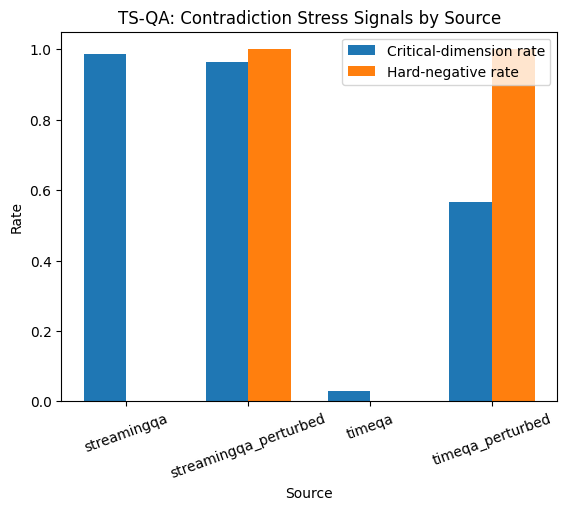

,source,hard_negative_rate,critical_dim_rate,n
0,streamingqa,0.0,0.987410,19778
1,streamingqa_perturbed,1.0,0.964395,3932
2,timeqa,0.0,0.030039,1032
3,timeqa_perturbed,1.0,0.565217,299


In [27]:
# Build per-example stats
rows = []
for ex in train:
    # hard negative
    hn = bool(ex["is_hard_negative"])
    
    # critical dimensions (parse JSON)
    try:
        obj = json.loads(ex["dimensions"])
        crit = bool(obj.get("has_critical_dimensions", False))
    except Exception:
        crit = False
    
    rows.append((ex["source"], hn, crit))

df = pd.DataFrame(rows, columns=["source", "is_hard_negative", "has_critical_dimensions"])

summary = df.groupby("source").agg(
    hard_negative_rate=("is_hard_negative", "mean"),
    critical_dim_rate=("has_critical_dimensions", "mean"),
    n=("source", "size"),
).reset_index()

# Keep a sensible order
order = ["streamingqa", "streamingqa_perturbed", "timeqa", "timeqa_perturbed"]
summary["source"] = pd.Categorical(summary["source"], categories=order, ordered=True)
summary = summary.sort_values("source")

# Plot
x = range(len(summary))
width = 0.35

plt.figure()
plt.bar([i - width/2 for i in x], summary["critical_dim_rate"], width, label="Critical-dimension rate")
plt.bar([i + width/2 for i in x], summary["hard_negative_rate"], width, label="Hard-negative rate")

plt.title("TS-QA: Contradiction Stress Signals by Source")
plt.xlabel("Source")
plt.ylabel("Rate")
plt.xticks(list(x), summary["source"], rotation=20)
plt.ylim(0, 1.05)
plt.legend()
plt.show()

display(summary)

Summary:

TS-QA Summary & Implications for Contradiction-Aware Sparse Memory

This exploratory analysis of the TS-QA dataset reveals several structural properties directly relevant to our Contradiction-Aware Sparse Memory Finetuning (CASF) objective.

1. Dataset Composition
- The training split contains 25,041 examples.
- 79% originate from streamingqa, with ~16% from streamingqa_perturbed.
- timeqa and timeqa_perturbed make up a smaller portion (~5%).

This indicates that the primary temporal reasoning signal comes from the StreamingQA subset.

2. Temporal Drift Structure
- The median question–evidence timestamp gap is 28 days.
- The distribution is highly right-skewed, with a long tail extending beyond 10 years.
- ~5% of examples have missing timestamps.

This confirms that TS-QA contains both short-term updates and long-term historical drift. A static memory would struggle with outdated facts under such temporal variation.

3. Contradiction Stress Signals
- All *_perturbed examples are hard negatives.
- StreamingQA examples have extremely high critical-dimension rates (~98%).
- Perturbed variants maintain high critical-dimension rates while introducing adversarial structure.

This suggests that perturbed splits explicitly simulate contradiction or temporal mismatch scenarios. These are ideal stress tests for contradiction-aware memory routing.

4. Structural Differences Across Sources
- streamingqa exhibits strong temporal and dimension sensitivity.
- timeqa shows substantially weaker critical-dimension annotation.
- Perturbation increases sensitivity signals in both subsets.

This highlights that StreamingQA provides the most appropriate benchmark slice for evaluating temporal contradiction handling.

Implications for CASF Design:

The TS-QA dataset motivates the following architectural components:

1. Versioned Memory Slots:
    - Facts must be indexed by time to prevent retrieval of outdated versions.

2. Temporal Routing Mechanism:
    - The model must select the correct memory slot based on the question timestamp.

3. Contradiction Detection Layer:
    - Hard-negative examples simulate inconsistent or misleading contexts, requiring robust conflict resolution.

4. Sparse Memory Updates:
    - Given the heavy skew in timestamp gaps, memory updates should prioritize high-sensitivity (critical-dimension) facts.